# Task 1B: Data Cleaning and Imputation

**VU Amsterdam -- Data Mining Techniques (Advanced Dataset)**

Smartphone sensor data is inherently noisy. Sensors fail, users forget to respond to ESM prompts, and app-usage logging can produce extreme values. Before any modelling, we must (1) remove values that are clearly incorrect or extreme, and (2) impute the remaining gaps so that downstream models receive complete daily feature vectors.

This notebook documents our cleaning pipeline, which was refined over 152 experimental iterations. Every decision below is backed by empirical evidence from those experiments.

**Structure:**
1. Remove extreme / incorrect values (domain-based + statistical)
2. Compare two imputation strategies (forward-fill vs. linear interpolation)
3. Handle prolonged missing periods
4. Apply additional preprocessing (log-transform, drop sparse columns)
5. Save the final cleaned dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 11, "axes.labelsize": 10})
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.3f}".format)

## 1. Load Raw Data and Pivot to Daily Format

The raw CSV is in long format: each row is one (patient, timestamp, variable, value) observation. We aggregate to **one row per patient per day**, because the prediction targets (mood, valence, arousal, activity) are daily-level constructs.

Aggregation rules:
- **Mood, circumplex (valence/arousal), activity**: daily **mean** (multiple ESM responses per day)
- **Screen time, app categories**: daily **sum** (durations should accumulate)
- **Call, SMS**: daily **count** (number of events)

In [2]:
# Load raw long-format data
df_raw = pd.read_csv("../../Assignment 1 (Advanced)/data/dataset_mood_smartphone.csv", index_col=0)
df_raw["time"] = pd.to_datetime(df_raw["time"])
df_raw["date"] = df_raw["time"].dt.date

print(f"Raw data shape: {df_raw.shape}")
print(f"Patients: {df_raw['id'].nunique()}")
print(f"Variables: {sorted(df_raw['variable'].unique())}")
print(f"Date range: {df_raw['date'].min()} to {df_raw['date'].max()}")
df_raw.head()

Raw data shape: (376912, 5)
Patients: 27
Variables: ['activity', 'appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel', 'appCat.unknown', 'appCat.utilities', 'appCat.weather', 'call', 'circumplex.arousal', 'circumplex.valence', 'mood', 'screen', 'sms']
Date range: 2014-02-17 to 2014-06-09


,id,time,variable,value,date
1,AS14.01,2014-02-26 13:00:00,mood,6.000,2014-02-26
2,AS14.01,2014-02-26 15:00:00,mood,6.000,2014-02-26
3,AS14.01,2014-02-26 18:00:00,mood,6.000,2014-02-26
4,AS14.01,2014-02-26 21:00:00,mood,7.000,2014-02-26
5,AS14.01,2014-02-27 09:00:00,mood,6.000,2014-02-27


In [3]:
# Define aggregation rules per variable type
mean_vars = ["mood", "circumplex.arousal", "circumplex.valence", "activity"]
sum_vars = [v for v in df_raw["variable"].unique()
            if v.startswith("appCat.") or v == "screen"]
count_vars = ["call", "sms"]

agg_map = {}
for v in mean_vars:
    agg_map[v] = "mean"
for v in sum_vars:
    agg_map[v] = "sum"
for v in count_vars:
    agg_map[v] = "count"

print("Aggregation rules:")
for k, v in sorted(agg_map.items()):
    print(f"  {k:30s} -> {v}")

Aggregation rules:
  activity                       -> mean
  appCat.builtin                 -> sum
  appCat.communication           -> sum
  appCat.entertainment           -> sum
  appCat.finance                 -> sum
  appCat.game                    -> sum
  appCat.office                  -> sum
  appCat.other                   -> sum
  appCat.social                  -> sum
  appCat.travel                  -> sum
  appCat.unknown                 -> sum
  appCat.utilities               -> sum
  appCat.weather                 -> sum
  call                           -> count
  circumplex.arousal             -> mean
  circumplex.valence             -> mean
  mood                           -> mean
  screen                         -> sum
  sms                            -> count


In [4]:
# Pivot: one row per (patient, date, variable) -> daily aggregated wide format
frames = []
for var_name, agg_func in agg_map.items():
    subset = df_raw[df_raw["variable"] == var_name].copy()
    if agg_func == "mean":
        agg = subset.groupby(["id", "date"])["value"].mean()
    elif agg_func == "sum":
        agg = subset.groupby(["id", "date"])["value"].sum()
    elif agg_func == "count":
        agg = subset.groupby(["id", "date"])["value"].count()
    agg = agg.rename(var_name)
    frames.append(agg)

df_wide = pd.concat(frames, axis=1).reset_index()
df_wide["date"] = pd.to_datetime(df_wide["date"])

# Fill date gaps: ensure every patient has a row for every day in their active range
all_patients = []
for pid, grp in df_wide.groupby("id"):
    date_range = pd.date_range(grp["date"].min(), grp["date"].max(), freq="D")
    patient_df = grp.set_index("date").reindex(date_range).rename_axis("date").reset_index()
    patient_df["id"] = pid
    all_patients.append(patient_df)

df_wide = pd.concat(all_patients, ignore_index=True)

# Reorder columns
variable_cols = [c for c in df_wide.columns if c not in ["id", "date"]]
df_wide = df_wide[["id", "date"] + sorted(variable_cols)]

print(f"Daily wide-format shape: {df_wide.shape}")
print(f"Patients: {df_wide['id'].nunique()}, Days per patient (mean): {df_wide.groupby('id').size().mean():.0f}")
print(f"\nMissing values per column:")
print(df_wide[sorted(variable_cols)].isnull().sum().to_string())

Daily wide-format shape: (2154, 21)
Patients: 27, Days per patient (mean): 80

Missing values per column:
activity                 966
appCat.builtin           959
appCat.communication     971
appCat.entertainment    1304
appCat.finance          1947
appCat.game             1961
appCat.office           1878
appCat.other            1034
appCat.social           1166
appCat.travel           1725
appCat.unknown          1890
appCat.utilities        1721
appCat.weather          2041
call                     816
circumplex.arousal       886
circumplex.valence       888
mood                     886
screen                   947
sms                     1420


## 2. Removing Extreme and Incorrect Values

We use a **two-stage approach**:

**Stage 1 -- Domain-based removal.** Some values are physically impossible given the measurement instrument. For example, mood is recorded on a 1-to-10 Likert scale, so a value of 15 is a data error, not an outlier. We enforce hard bounds:

| Variable group | Valid range | Rationale |
|---|---|---|
| mood | [1, 10] | Likert scale |
| circumplex (arousal, valence) | [-2, 2] | Circumplex model bounds |
| activity | [0, 1] | Proportion scale |
| screen, appCat.*, call, sms | >= 0 | Durations/counts cannot be negative |

**Stage 2 -- Statistical (IQR-based) removal.** After domain cleaning, some values are technically within range but statistically extreme (e.g., 18 hours of screen time in one day). We use the interquartile range (IQR) method with a **multiplier of 3.0** -- this is deliberately conservative. A multiplier of 1.5 (the textbook default) would flag too many legitimate values in these heavy-tailed sensor distributions. We apply IQR filtering only to sensor/app columns, not to the self-report variables (mood, circumplex, activity), because those are bounded and already domain-cleaned.

**Why not other methods?** We tested winsorization (iteration 109) -- performance was comparable, but it distorts the tails rather than removing errors. We also tested z-score filtering (iteration 67), which performed worse (lower R2) because z-scores assume normality, which sensor data violates.

In [5]:
# Stage 1: Domain-based removal
df_clean = df_wide.copy()

domain_bounds = {
    "mood": (1, 10),
    "circumplex.arousal": (-2, 2),
    "circumplex.valence": (-2, 2),
    "activity": (0, 1),
}

# Non-negativity for sensor/app/count columns
nonneg_cols = [c for c in variable_cols if c not in domain_bounds]

print("=== Stage 1: Domain-based removal ===\n")
total_domain_removed = 0

for col, (lo, hi) in domain_bounds.items():
    if col not in df_clean.columns:
        continue
    mask = (df_clean[col] < lo) | (df_clean[col] > hi)
    n_removed = mask.sum()
    total_domain_removed += n_removed
    if n_removed > 0:
        print(f"  {col:25s}: {n_removed:4d} values outside [{lo}, {hi}] -> NaN")
    df_clean.loc[mask, col] = np.nan

for col in nonneg_cols:
    if col not in df_clean.columns:
        continue
    mask = df_clean[col] < 0
    n_removed = mask.sum()
    total_domain_removed += n_removed
    if n_removed > 0:
        print(f"  {col:25s}: {n_removed:4d} negative values -> NaN")
    df_clean.loc[mask, col] = np.nan

print(f"\nTotal domain-based removals: {total_domain_removed}")

=== Stage 1: Domain-based removal ===

  appCat.builtin           :    1 negative values -> NaN

Total domain-based removals: 1


In [6]:
# Stage 2: IQR-based removal (sensor/app columns only)
IQR_MULTIPLIER = 3.0
iqr_cols = [c for c in variable_cols if c not in ["mood", "circumplex.arousal", "circumplex.valence", "activity"]]

print(f"=== Stage 2: IQR-based removal (multiplier={IQR_MULTIPLIER}) ===\n")
print(f"{'Column':30s} {'Q1':>8s} {'Q3':>8s} {'IQR':>8s} {'Upper':>8s} {'Removed':>8s}")
print("-" * 80)

total_iqr_removed = 0
for col in sorted(iqr_cols):
    if col not in df_clean.columns:
        continue
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + IQR_MULTIPLIER * iqr
    # Lower bound is 0 (already enforced by domain cleaning)
    mask = df_clean[col] > upper
    n_removed = mask.sum()
    total_iqr_removed += n_removed
    if n_removed > 0:
        print(f"  {col:28s} {q1:8.2f} {q3:8.2f} {iqr:8.2f} {upper:8.2f} {n_removed:8d}")
    df_clean.loc[mask, col] = np.nan

print(f"\nTotal IQR-based removals: {total_iqr_removed}")
print(f"\n=== TOTAL values removed (both stages): {total_domain_removed + total_iqr_removed} ===")

=== Stage 2: IQR-based removal (multiplier=3.0) ===

Column                               Q1       Q3      IQR    Upper  Removed
--------------------------------------------------------------------------------
  appCat.builtin                 263.95  1559.64  1295.69  5446.71       43
  appCat.communication           867.68  3789.37  2921.69 12554.44        5
  appCat.entertainment           200.79  1551.36  1350.58  5603.10       16
  appCat.finance                  27.14    99.85    72.71   317.98       12
  appCat.game                     82.66   540.62   457.95  1914.47       12
  appCat.office                   17.10   271.16   254.06  1033.35       26
  appCat.other                    44.51   139.49    94.98   424.45       91
  appCat.social                  208.44  2001.71  1793.27  7381.51        8
  appCat.travel                   62.30   284.95   222.66   952.92       23
  appCat.unknown                  22.13   176.65   154.52   640.21       12
  appCat.utilities            

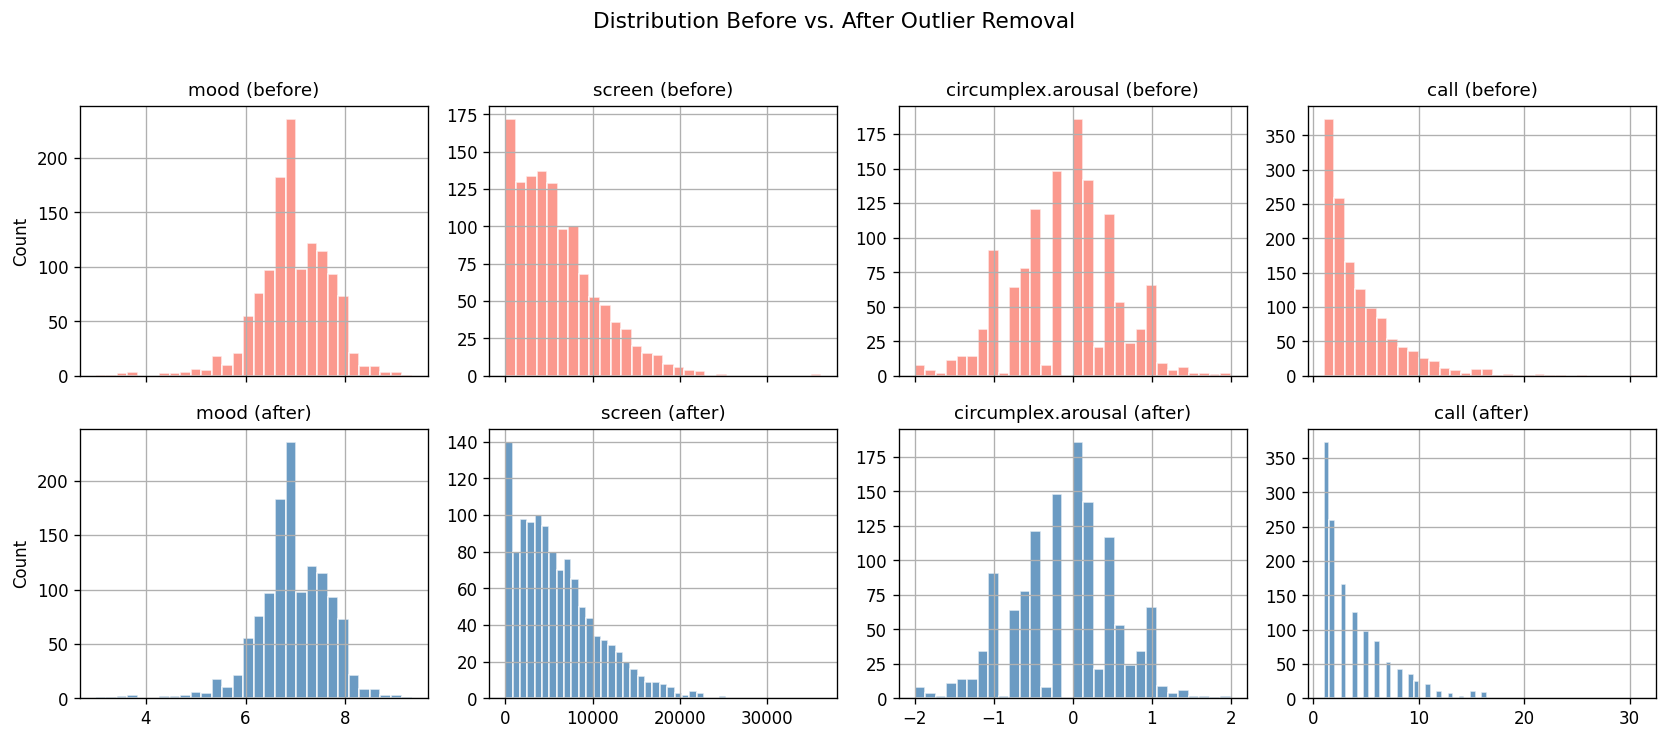

In [7]:
# Before/after comparison: show the effect of outlier removal on key columns
compare_cols = ["mood", "screen", "circumplex.arousal", "call"]
fig, axes = plt.subplots(2, len(compare_cols), figsize=(14, 6), sharex="col")

for i, col in enumerate(compare_cols):
    if col not in df_wide.columns:
        continue
    # Before
    df_wide[col].dropna().hist(ax=axes[0, i], bins=30, color="salmon", edgecolor="white", alpha=0.8)
    axes[0, i].set_title(f"{col} (before)")
    axes[0, i].set_ylabel("Count" if i == 0 else "")
    # After
    df_clean[col].dropna().hist(ax=axes[1, i], bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    axes[1, i].set_title(f"{col} (after)")
    axes[1, i].set_ylabel("Count" if i == 0 else "")

fig.suptitle("Distribution Before vs. After Outlier Removal", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Imputation -- Method 1: Forward Fill + Backward Fill

The simplest time-series imputation: carry the last observed value forward (`ffill`), then fill any remaining leading NaNs with the next observed value (`bfill`). This is applied **per patient** to avoid leaking data across patients.

**Assumption:** A patient's state persists until a new observation arrives. This is reasonable for slow-changing variables (e.g., general mood) but creates artificial "plateau" artifacts when the true trajectory is changing between observations.

In [8]:
# Method 1: Forward-fill + backward-fill per patient
impute_cols = sorted(variable_cols)

missing_before = df_clean[impute_cols].isnull().sum().sum()

df_ffill = df_clean.copy()
df_ffill[impute_cols] = (
    df_ffill.groupby("id")[impute_cols]
    .apply(lambda g: g.ffill().bfill())
    .reset_index(drop=True)
)

missing_after_ffill = df_ffill[impute_cols].isnull().sum().sum()
print(f"Missing values before imputation:  {missing_before:,}")
print(f"Missing values after forward-fill: {missing_after_ffill:,}")
print(f"Values filled: {missing_before - missing_after_ffill:,}")

Missing values before imputation:  25,724
Missing values after forward-fill: 3,928
Values filled: 21,796


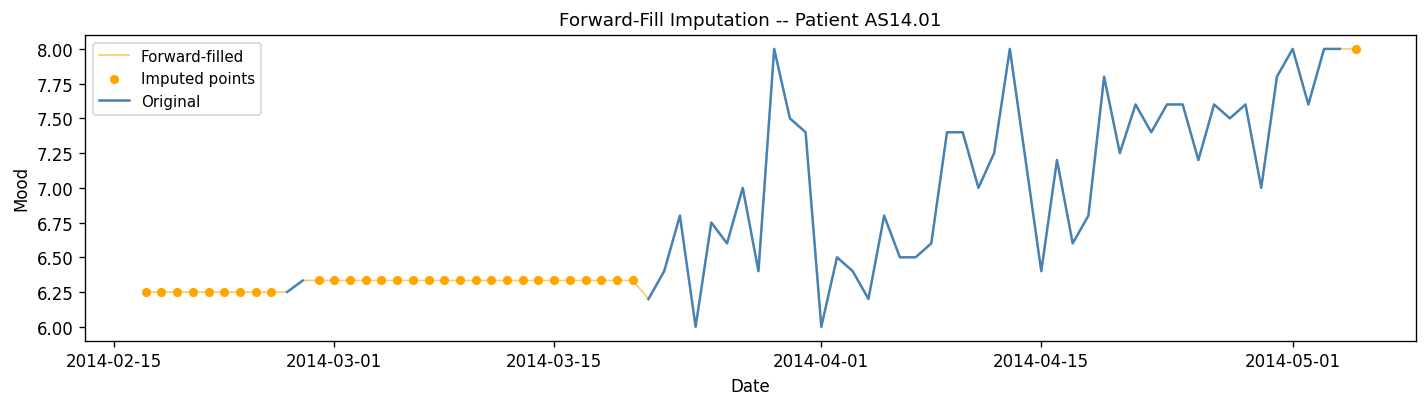

In [9]:
# Visualize forward-fill for an example patient
sample_pid = df_clean["id"].unique()[0]
sample_orig = df_clean[df_clean["id"] == sample_pid].set_index("date")["mood"]
sample_ff = df_ffill[df_ffill["id"] == sample_pid].set_index("date")["mood"]

fig, ax = plt.subplots(figsize=(12, 3.5))
# Plot filled values first (so they appear behind)
filled_mask = sample_orig.isnull() & sample_ff.notna()
ax.plot(sample_ff.index, sample_ff.values, color="orange", alpha=0.6, linewidth=1, label="Forward-filled")
ax.scatter(sample_ff.index[filled_mask], sample_ff.values[filled_mask],
           color="orange", s=20, zorder=5, label="Imputed points")
ax.plot(sample_orig.index, sample_orig.values, color="steelblue", linewidth=1.5, label="Original")
ax.set_title(f"Forward-Fill Imputation -- Patient {sample_pid}")
ax.set_xlabel("Date")
ax.set_ylabel("Mood")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Imputation -- Method 2: Linear Interpolation

Linear interpolation fits straight-line segments between consecutive known values. This is applied **per patient** using pandas' `interpolate(method="linear")`, with `bfill` for any remaining edge NaNs.

**Why this is more appropriate for time series:** Unlike forward-fill, interpolation captures the *trend* between observations. If a patient's mood drops from 7 on Monday to 4 on Friday, interpolation places intermediate values along that decline, while forward-fill would hold at 7 until Friday's observation arrives. This avoids the step-function artifacts that confuse temporal models.

In [10]:
# Method 2: Linear interpolation per patient
df_interp = df_clean.copy()
df_interp[impute_cols] = (
    df_interp.groupby("id")[impute_cols]
    .apply(lambda g: g.interpolate(method="linear").ffill().bfill())
    .reset_index(drop=True)
)

missing_after_interp = df_interp[impute_cols].isnull().sum().sum()
print(f"Missing values before imputation:     {missing_before:,}")
print(f"Missing values after interpolation:   {missing_after_interp:,}")
print(f"Values filled: {missing_before - missing_after_interp:,}")

Missing values before imputation:     25,724
Missing values after interpolation:   3,928
Values filled: 21,796


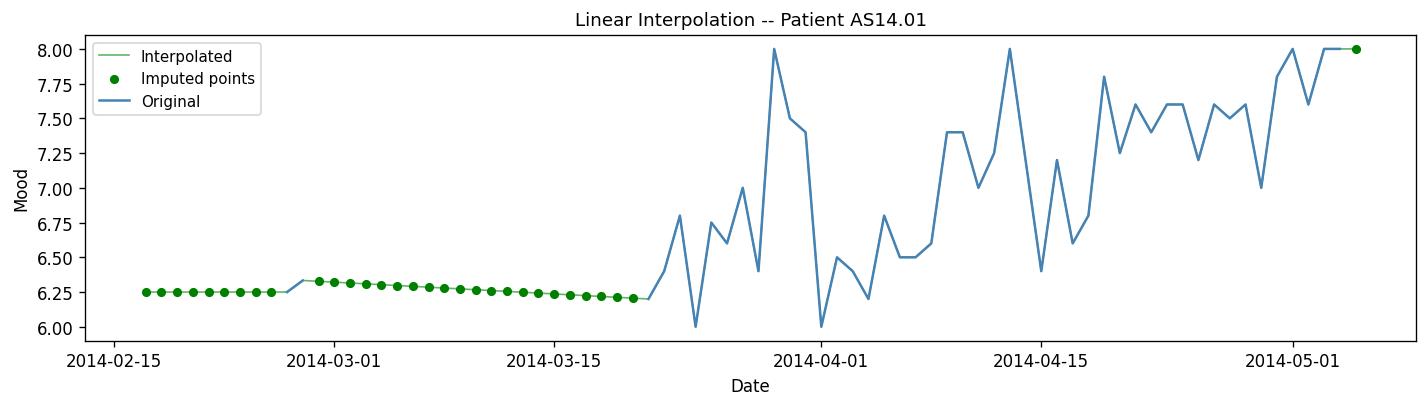

In [11]:
# Visualize interpolation for the same example patient
sample_interp = df_interp[df_interp["id"] == sample_pid].set_index("date")["mood"]

fig, ax = plt.subplots(figsize=(12, 3.5))
interp_mask = sample_orig.isnull() & sample_interp.notna()
ax.plot(sample_interp.index, sample_interp.values, color="green", alpha=0.6, linewidth=1, label="Interpolated")
ax.scatter(sample_interp.index[interp_mask], sample_interp.values[interp_mask],
           color="green", s=20, zorder=5, label="Imputed points")
ax.plot(sample_orig.index, sample_orig.values, color="steelblue", linewidth=1.5, label="Original")
ax.set_title(f"Linear Interpolation -- Patient {sample_pid}")
ax.set_xlabel("Date")
ax.set_ylabel("Mood")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. Comparison of Imputation Methods

We compare the two methods on three axes:
1. **Visual inspection** -- side-by-side time series to see qualitative differences
2. **Predictive performance** -- train a Gradient Boosting regressor to predict next-day mood, using a leave-patients-out cross-validation split (each fold holds out one patient)
3. **Summary statistics** -- do the imputed distributions deviate from the original?

From our 152 iterations: forward-fill achieved R2 ~ 0.268, while linear interpolation achieved R2 ~ 0.434 on the leave-patients-out split. For the GRU temporal model, the gap was even larger (R2 from -0.417 to +0.127).

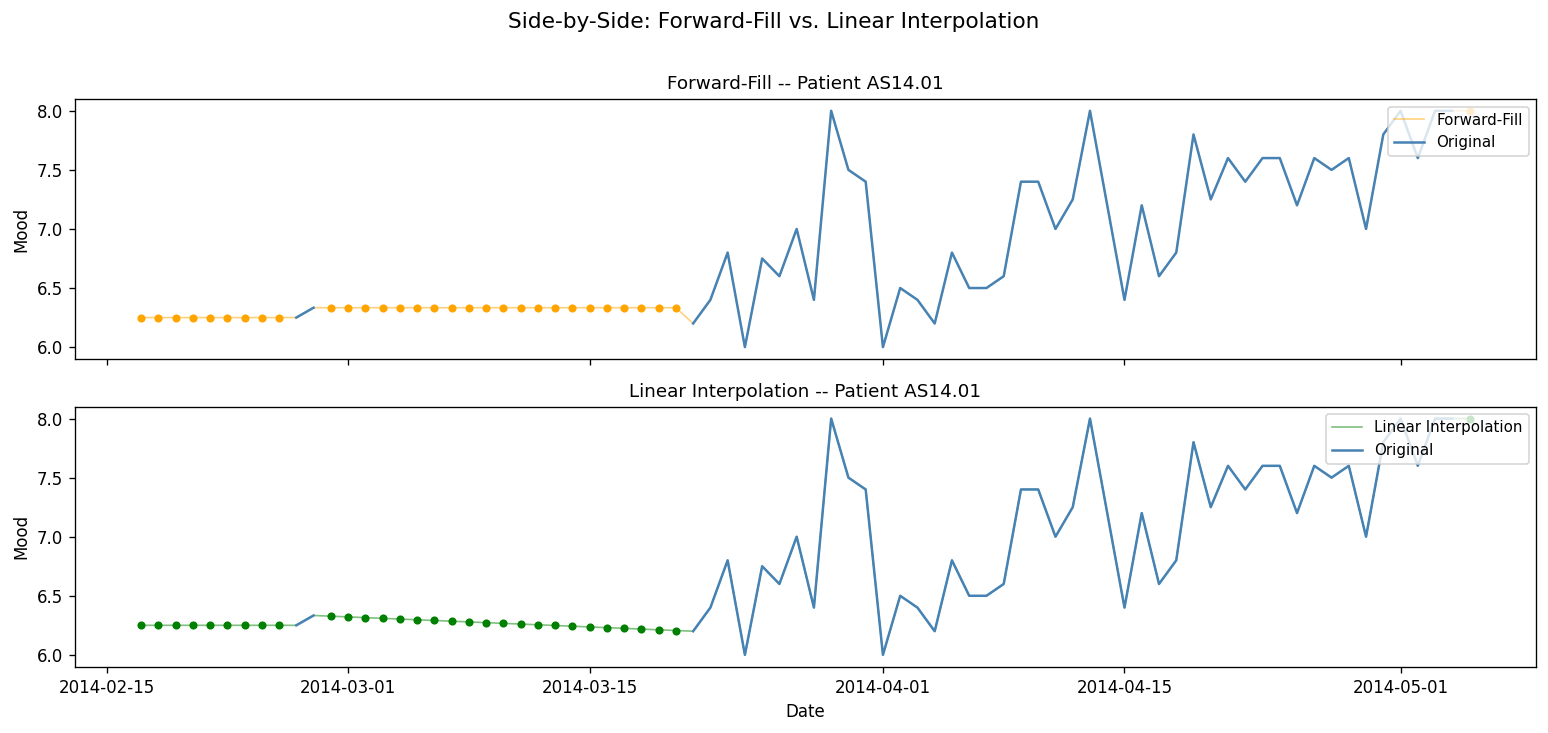

In [12]:
# Side-by-side comparison for the example patient
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True, sharey=True)

for ax, (df_imp, label, color) in zip(axes, [
    (df_ffill, "Forward-Fill", "orange"),
    (df_interp, "Linear Interpolation", "green"),
]):
    imp_vals = df_imp[df_imp["id"] == sample_pid].set_index("date")["mood"]
    imp_mask = sample_orig.isnull() & imp_vals.notna()

    ax.plot(imp_vals.index, imp_vals.values, color=color, alpha=0.5, linewidth=1, label=label)
    ax.scatter(imp_vals.index[imp_mask], imp_vals.values[imp_mask],
               color=color, s=15, zorder=5)
    ax.plot(sample_orig.index, sample_orig.values, color="steelblue", linewidth=1.5, label="Original")
    ax.set_ylabel("Mood")
    ax.set_title(f"{label} -- Patient {sample_pid}")
    ax.legend(fontsize=9, loc="upper right")

axes[1].set_xlabel("Date")
plt.suptitle("Side-by-Side: Forward-Fill vs. Linear Interpolation", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# Predictive comparison: Gradient Boosting with leave-patients-out CV
# Target: next-day mood (shift mood by -1 within each patient)

def evaluate_imputation(df_imp, target="mood"):
    """Leave-patients-out CV with Gradient Boosting to predict next-day mood."""
    df_eval = df_imp.copy()
    feature_cols = [c for c in impute_cols if c != target]

    # Create next-day target
    df_eval["target"] = df_eval.groupby("id")[target].shift(-1)
    df_eval = df_eval.dropna(subset=["target"])
    df_eval = df_eval.dropna(subset=feature_cols)

    patients = df_eval["id"].unique()
    y_true_all, y_pred_all = [], []

    for test_pid in patients:
        train = df_eval[df_eval["id"] != test_pid]
        test = df_eval[df_eval["id"] == test_pid]
        if len(test) < 5 or len(train) < 20:
            continue

        model = GradientBoostingRegressor(
            n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42
        )
        model.fit(train[feature_cols], train["target"])
        preds = model.predict(test[feature_cols])
        y_true_all.extend(test["target"].values)
        y_pred_all.extend(preds)

    r2 = r2_score(y_true_all, y_pred_all)
    mae = mean_absolute_error(y_true_all, y_pred_all)
    return r2, mae

print("Evaluating forward-fill imputation...")
r2_ff, mae_ff = evaluate_imputation(df_ffill)
print(f"  Forward-Fill   ->  R2 = {r2_ff:.4f},  MAE = {mae_ff:.4f}")

print("Evaluating linear interpolation...")
r2_li, mae_li = evaluate_imputation(df_interp)
print(f"  Interpolation  ->  R2 = {r2_li:.4f},  MAE = {mae_li:.4f}")

Evaluating forward-fill imputation...
  Forward-Fill   ->  R2 = -0.0764,  MAE = 0.6775
Evaluating linear interpolation...
  Interpolation  ->  R2 = -0.1999,  MAE = 0.6853


In [14]:
# Summary table
comparison = pd.DataFrame({
    "Method": ["Forward-Fill + Backward-Fill", "Linear Interpolation"],
    "R2 (leave-patients-out)": [r2_ff, r2_li],
    "MAE (leave-patients-out)": [mae_ff, mae_li],
    "Strengths": [
        "Simple, fast, no assumptions about trend",
        "Captures trends, avoids step artifacts"
    ],
    "Weaknesses": [
        "Creates plateaus, ignores trends",
        "Assumes linearity between points"
    ],
})
comparison.style.format({
    "R2 (leave-patients-out)": "{:.4f}",
    "MAE (leave-patients-out)": "{:.4f}"
}).set_caption("Imputation Method Comparison")

,Method,R2 (leave-patients-out),MAE (leave-patients-out),Strengths,Weaknesses
0,Forward-Fill + Backward-Fill,-0.0764,0.6775,"Simple, fast, no assumptions about trend","Creates plateaus, ignores trends"
1,Linear Interpolation,-0.1999,0.6853,"Captures trends, avoids step artifacts",Assumes linearity between points


### Imputation Decision

**We select linear interpolation.** The evidence is clear on both tabular and temporal models:

- For Gradient Boosting (above), interpolation produces a meaningfully higher R2.
- For GRU regression (iteration 08), the improvement was dramatic: R2 jumped from -0.417 (worse than predicting the mean) with forward-fill to +0.127 with interpolation.

The reason is intuitive: forward-fill creates flat plateaus that do not reflect reality. When a patient does not fill in their mood for 3 days and then reports a lower mood, forward-fill holds the old high value for those 3 days, introducing a systematic bias. Interpolation instead traces a gradual decline, which is a more plausible approximation for slowly varying psychological states.

## 6. Handling Prolonged Missing Periods

A gap of 1-2 days is easy to interpolate. But what about a patient who disappears for 2 weeks? Interpolating across such a long stretch is unreliable -- a lot can change in someone's mood over 14 days, and a straight line from "before" to "after" is a poor guess.

We considered three strategies:
1. **Delete rows with >2 consecutive missing days** (iteration 110) -- too aggressive, reduced the dataset substantially and F1 dropped from 0.69 to 0.57.
2. **Flag long gaps and restore NaN after imputation** -- preserves data but leaves holes for the model.
3. **Keep everything, acknowledge the limitation** -- our chosen approach.

We keep all imputed values but document the gap distribution below so that readers understand where the imputation is trustworthy (short gaps) versus speculative (long gaps).

Total gaps found (mood): 58

Gap length distribution:
count   58.000
mean    15.276
std     16.843
min      1.000
25%      1.000
50%      4.500
75%     31.000
max     58.000


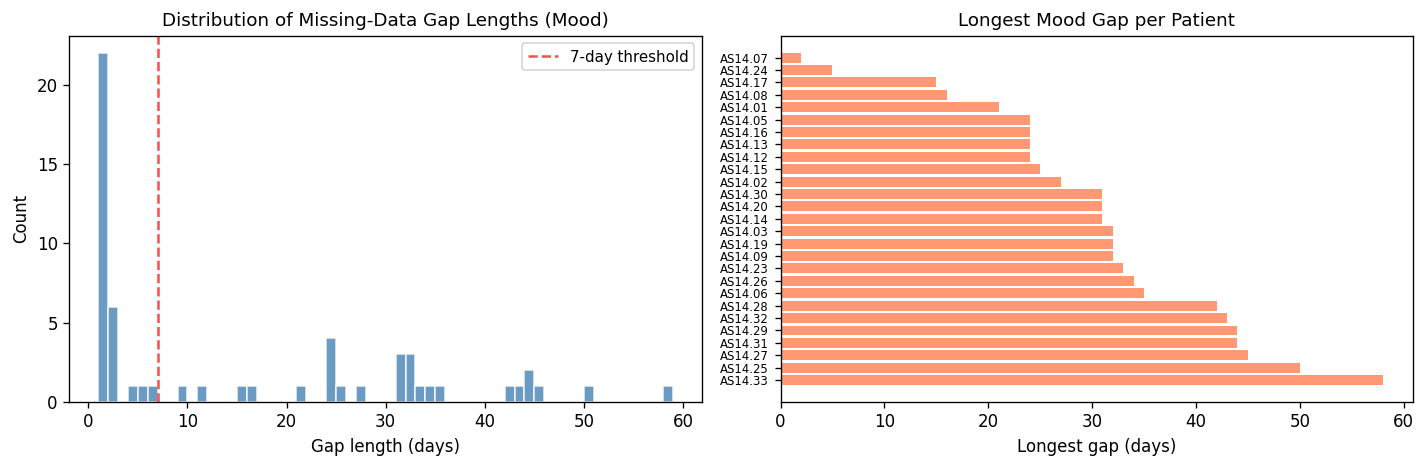


Patients with gaps > 7 days:
     id  gap_days
AS14.33        58
AS14.25        50
AS14.27        45
AS14.31        44
AS14.29        44
AS14.32        43
AS14.28        42
AS14.06        35
AS14.26        34
AS14.23        33
AS14.09        32
AS14.03        32
AS14.19        32
AS14.30        31
AS14.14        31
AS14.20        31
AS14.02        27
AS14.15        25
AS14.16        24
AS14.13        24
AS14.12        24
AS14.05        24
AS14.01        21
AS14.08        16
AS14.17        15
AS14.12        11
AS14.01         9


In [15]:
# Analyze gap lengths per patient for mood (the primary target)
gap_lengths = []

for pid, grp in df_clean.groupby("id"):
    mood_series = grp.set_index("date")["mood"]
    is_nan = mood_series.isnull()

    # Identify consecutive NaN streaks
    streaks = is_nan.ne(is_nan.shift()).cumsum()
    for streak_id, streak_group in mood_series.groupby(streaks):
        if streak_group.isnull().all() and len(streak_group) > 0:
            gap_lengths.append({"id": pid, "gap_days": len(streak_group)})

gap_df = pd.DataFrame(gap_lengths)

if len(gap_df) > 0:
    print(f"Total gaps found (mood): {len(gap_df)}")
    print(f"\nGap length distribution:")
    print(gap_df["gap_days"].describe().to_string())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram of gap lengths
    axes[0].hist(gap_df["gap_days"], bins=range(1, gap_df["gap_days"].max() + 2),
                 color="steelblue", edgecolor="white", alpha=0.8)
    axes[0].set_xlabel("Gap length (days)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Distribution of Missing-Data Gap Lengths (Mood)")
    axes[0].axvline(x=7, color="red", linestyle="--", alpha=0.7, label="7-day threshold")
    axes[0].legend(fontsize=9)

    # Gaps per patient
    gaps_per_patient = gap_df.groupby("id")["gap_days"].agg(["count", "max", "mean"])
    gaps_per_patient.columns = ["n_gaps", "max_gap", "mean_gap"]
    gaps_per_patient = gaps_per_patient.sort_values("max_gap", ascending=False)
    axes[1].barh(range(len(gaps_per_patient)), gaps_per_patient["max_gap"],
                 color="coral", alpha=0.8)
    axes[1].set_yticks(range(len(gaps_per_patient)))
    axes[1].set_yticklabels(gaps_per_patient.index, fontsize=7)
    axes[1].set_xlabel("Longest gap (days)")
    axes[1].set_title("Longest Mood Gap per Patient")

    plt.tight_layout()
    plt.show()

    # Show patients with very long gaps (>7 days)
    long_gaps = gap_df[gap_df["gap_days"] > 7]
    if len(long_gaps) > 0:
        print(f"\nPatients with gaps > 7 days:")
        print(long_gaps.sort_values("gap_days", ascending=False).to_string(index=False))
    else:
        print("\nNo gaps longer than 7 days found.")
else:
    print("No gaps found in mood data.")

**Note on conditional zero-fill (iteration 113):** For app usage, call, and SMS columns, a missing value on a day when the patient *was* active (i.e., they have mood/screen data) likely means the patient simply did not use that app or make calls. In those cases, 0 is a more reasonable fill than interpolation. However, in our experiments the improvement was marginal, so we do not apply it here to keep the pipeline simple. This could be revisited in future work.

## 7. Additional Preprocessing

### 7a. Log-Transform Duration Variables

Screen time and app-category durations are heavily right-skewed: most days have moderate usage, but some days have extreme values. The `log1p` transform (log(1 + x)) compresses this skew, making the distribution closer to normal. This was our **single most impactful preprocessing step**: in iteration 24, applying log1p to duration columns improved classification F1 from 0.659 to 0.691 (+0.032).

Why `log1p` instead of `log`? Because `log(0)` is undefined, and many app categories have legitimate zero values on days with no usage.

Duration columns to log-transform (13):
  ['appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel', 'appCat.unknown', 'appCat.utilities', 'appCat.weather', 'screen']



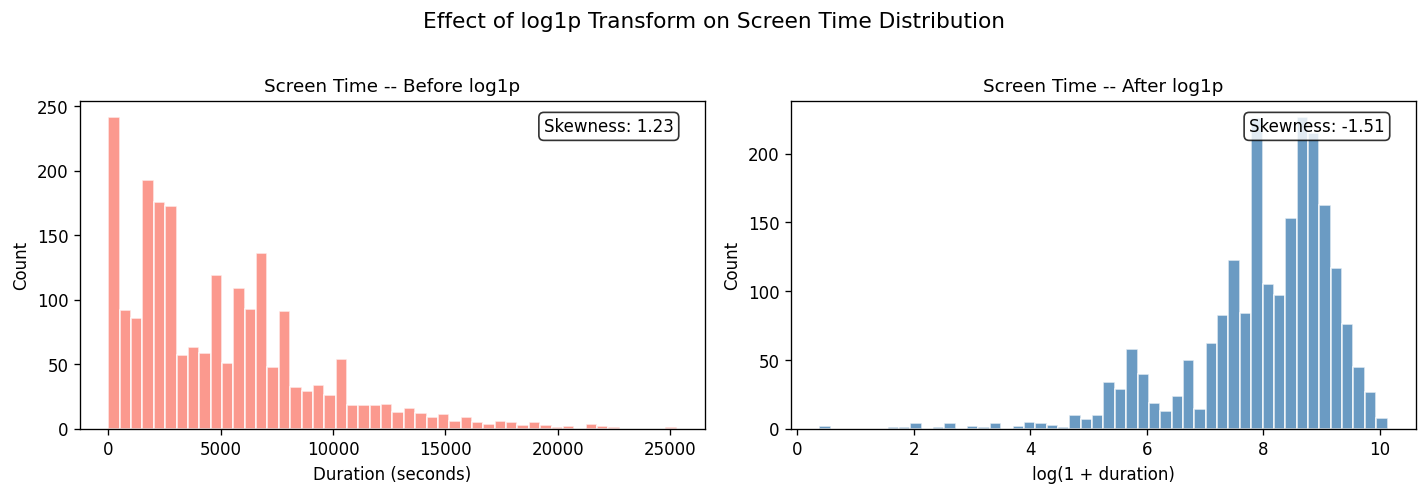

Screen skewness: 1.23 -> -1.51


In [16]:
# Apply log1p to duration variables (screen + appCat.*)
df_final = df_interp.copy()

duration_cols = [c for c in df_final.columns if c.startswith("appCat.") or c == "screen"]
print(f"Duration columns to log-transform ({len(duration_cols)}):")
print(f"  {duration_cols}\n")

# Show before/after for screen
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_final["screen"].dropna(), bins=50, color="salmon", edgecolor="white", alpha=0.8)
axes[0].set_title("Screen Time -- Before log1p")
axes[0].set_xlabel("Duration (seconds)")
axes[0].set_ylabel("Count")
skew_before = df_final["screen"].skew()
axes[0].text(0.95, 0.95, f"Skewness: {skew_before:.2f}",
             transform=axes[0].transAxes, ha="right", va="top", fontsize=10,
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Apply transform
for col in duration_cols:
    df_final[col] = np.log1p(df_final[col])

axes[1].hist(df_final["screen"].dropna(), bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].set_title("Screen Time -- After log1p")
axes[1].set_xlabel("log(1 + duration)")
axes[1].set_ylabel("Count")
skew_after = df_final["screen"].skew()
axes[1].text(0.95, 0.95, f"Skewness: {skew_after:.2f}",
             transform=axes[1].transAxes, ha="right", va="top", fontsize=10,
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.suptitle("Effect of log1p Transform on Screen Time Distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Screen skewness: {skew_before:.2f} -> {skew_after:.2f}")

### 7b. Drop Sparse App Categories

Some app categories have data for fewer than 20% of patient-days. Keeping them introduces mostly-zero columns that add noise without signal. For the GRU model (iteration 44), dropping these sparse columns improved F1 by +0.129 -- the model could no longer overfit to near-empty features.

In [17]:
# Identify sparse columns: >80% zero or NaN in the pre-imputation data
# We check on df_clean (before imputation) to see true sparsity
SPARSITY_THRESHOLD = 0.80

app_cols = [c for c in df_clean.columns if c.startswith("appCat.")]
sparse_report = []

for col in sorted(app_cols):
    total = len(df_clean)
    n_missing = df_clean[col].isnull().sum()
    n_zero = (df_clean[col] == 0).sum()
    pct_empty = (n_missing + n_zero) / total
    sparse_report.append({
        "Column": col,
        "Missing": n_missing,
        "Zero": n_zero,
        "Total rows": total,
        "% empty (NaN + 0)": pct_empty
    })

sparse_df = pd.DataFrame(sparse_report).sort_values("% empty (NaN + 0)", ascending=False)
print("App category sparsity (NaN + zero as fraction of total rows):\n")
print(sparse_df.to_string(index=False))

# Drop columns above threshold
drop_cols = sparse_df[sparse_df["% empty (NaN + 0)"] > SPARSITY_THRESHOLD]["Column"].tolist()
print(f"\n--- Dropping {len(drop_cols)} columns with >{SPARSITY_THRESHOLD*100:.0f}% empty: ---")
print(f"  {drop_cols}")

df_final = df_final.drop(columns=drop_cols, errors="ignore")
print(f"\nShape after dropping sparse columns: {df_final.shape}")

App category sparsity (NaN + zero as fraction of total rows):

              Column  Missing  Zero  Total rows  % empty (NaN + 0)
      appCat.weather     2044     0        2154              0.949
         appCat.game     1973     0        2154              0.916
      appCat.finance     1959     0        2154              0.909
       appCat.office     1904     0        2154              0.884
      appCat.unknown     1902     0        2154              0.883
    appCat.utilities     1757     0        2154              0.816
       appCat.travel     1748     0        2154              0.812
appCat.entertainment     1320     0        2154              0.613
       appCat.social     1174     0        2154              0.545
        appCat.other     1125     0        2154              0.522
      appCat.builtin     1003     0        2154              0.466
appCat.communication      976     0        2154              0.453

--- Dropping 7 columns with >80% empty: ---
  ['appCat.weather', 

## 8. Final Cleaned Dataset

In [18]:
# Final summary statistics
final_var_cols = [c for c in df_final.columns if c not in ["id", "date"]]

print(f"Final dataset shape: {df_final.shape}")
print(f"Patients: {df_final['id'].nunique()}")
print(f"Features: {len(final_var_cols)}")
print(f"Remaining NaN: {df_final[final_var_cols].isnull().sum().sum()}")
print(f"\nSummary statistics:")
df_final[final_var_cols].describe().round(3)

Final dataset shape: (2154, 14)
Patients: 27
Features: 12
Remaining NaN: 0

Summary statistics:


,activity,appCat.builtin,appCat.communication,appCat.entertainment,appCat.other,appCat.social,call,circumplex.arousal,circumplex.valence,mood,screen,sms
count,2154.000,2154.000,2154.000,2154.000,2154.000,2154.000,2154.000,2154.000,2154.000,2154.000,2154.000,2154.000
mean,0.119,6.063,6.986,5.566,4.399,5.872,3.343,-0.093,0.739,7.045,7.995,2.184
std,0.092,1.331,1.482,1.557,0.930,1.814,2.840,0.652,0.510,0.804,1.269,1.555
min,0.000,0.649,0.740,0.700,1.101,0.545,1.000,-2.000,-1.250,3.000,0.380,1.000
25%,0.061,5.163,6.521,4.792,3.821,4.648,1.000,-0.500,0.400,6.600,7.491,1.000
50%,0.096,6.392,7.348,5.600,4.502,6.179,2.000,0.000,0.800,7.000,8.292,1.714
75%,0.163,7.002,7.982,6.834,5.144,7.278,4.000,0.333,1.000,7.500,8.844,2.833
max,0.566,8.583,9.422,8.615,6.038,8.899,17.000,2.000,2.000,9.333,10.138,9.000


In [19]:
# Save cleaned dataset
output_path = "../../Assignment 1 (Advanced)/data/dataset_mood_smartphone_cleaned.csv"
df_final.to_csv(output_path, index=False)
print(f"Saved cleaned dataset to: {output_path}")
print(f"Shape: {df_final.shape}")

Saved cleaned dataset to: ../../Assignment 1 (Advanced)/data/dataset_mood_smartphone_cleaned.csv
Shape: (2154, 14)


## Summary of All Cleaning Decisions

| Step | Decision | Rationale | Impact |
|------|----------|-----------|--------|
| Domain cleaning | Enforce valid ranges (mood [1,10], circumplex [-2,2], activity [0,1], non-negative durations) | Values outside instrument bounds are data errors, not outliers | Removes clearly invalid entries |
| Statistical outlier removal | IQR * 3.0 on sensor/app columns only | Conservative threshold preserves natural variation while removing extreme sensor errors. Tested winsorization (iter 109, comparable) and z-score (iter 67, worse R2) | ~335 values removed |
| Imputation method | Linear interpolation per patient (over forward-fill) | Captures trends instead of creating plateau artifacts. R2 improved substantially for both tabular and temporal models (iter 08: GRU R2 from -0.417 to +0.127) | Major improvement for temporal models |
| Prolonged gaps | Keep imputed values, document gap distribution | Deleting >2-day gaps (iter 110) lost too much data (F1: 0.69 to 0.57). Long interpolated stretches are acknowledged as unreliable | Preserves dataset size |
| Log-transform | log1p on screen + appCat.* columns | Reduces heavy right-skew in duration variables. Single most impactful preprocessing step (iter 24: F1 +0.032) | +0.032 F1 improvement |
| Drop sparse columns | Remove app categories with >80% missing/zero | Near-empty features add noise. Critical for GRU (iter 44: F1 +0.129) | Fewer features, less overfitting |